# Procesamiento del Lenguaje Natural
# Práctica 6: Análisis de Emociones y Sentimiento

Grupo 10:
- Prieto Maffla, Agustín
- Tejera Munguía, Violeta

## Ejercicio 1: Construye un dataset sintético de frases y emociones.

Comenzamos descargándonos el Word-Emotion Association Lexicon del NRC y trabajando con el fichero en castellano. Puesto que se trata de una práctica sobre *sentiment analysis*, hemos preprocesado el archivo para eliminar todas aquellas entradas referentes a palabras sin ninguna emoción asociada, como es el caso de "aback". El dataset ha pasado de tener $14154$ unigramas a $6453$, es decir, nos hemos quedado con el $\sim 45.6\%$ del dataset.

A su vez, hemos eliminado la columna con la traducción al castellano de los vocablos (No encontramos este archivo directamente en inglés, por eso hemos hecho este paso extra).

In [49]:
import pandas as pd

df = pd.read_csv("Spanish-NRC-EmoLex.txt", sep="\t")

emotion_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "negative", "positive", "sadness", "surprise",
    "trust"
]

# Quitamos las palabras que no tienen asociada ninguna emoción
df = df[df[emotion_cols].sum(axis=1) > 0]

# Quitamos la columna con la palabra traducida al castellano
df = df[["English Word"] +emotion_cols]

df.head()
df.to_csv("FILTRADO-Spanish-NRC-EmoLex.txt", header=["English Word"]+emotion_cols, sep="\t")


GPT 5.4 Thinking
Prompt 1:
Quiero que extiendas este dataset para agregar una columna nueva que se llame phrase que contenga una frase en inglés con esa palabra, respetando las emociones de la fila y polarización (positive, negative), devuelveme un nuevo csv

Prompt 2:
Quiero que extiendas este dataset para agregar una columna nueva que se llame phrase que contenga una frase de ejemplo en inglés utilizando esa palabra, respetando las emociones de la fila y polarización (positive, negative) al crear la frase, devuelveme un nuevo csv

Prompt 3:
Mensaje 1:
Quiero que extiendas este dataset para agregar una columna nueva que se llame phrase que contenga una frase de ejemplo en inglés utilizando esa palabra, tiene que ser una frase aleatoria que utilice dicha palabra de forma natural, respetando las emociones de la fila y polarización (positive, negative) al crear la frase, devuelveme un nuevo csv no me sirve que hagas algo del estilo: Hearing ""abacus"" gave people a sense of reliability and trust., no tiene que ser una frase creativa donde se use en el contexto adecuado, no puedes usar una librería, las tienes que crear tú de forma natural, espero que lleve tiempo

Mensaje 2:
Hay mucha repeticion, las frases tienen que ser unicas, si quieres lo puedes ir generando por tandas y uniendolos, pero espero que demore mucho

Mensaje 3: 
Tienen que ser únicas y la palbra tiene que tenir sentido contextual en la frase, no simplmente que aparezca

Resultados Descartados

Con Gemini Model 3 Flash:

Prompt:

We are working with the following lexicon and wish to create a synthetic based on it with sentences that are tagged with different emotions (anger, anticipation,...) and their polarity (positive or negative). We want 1000 random sentences in English that use words from the lexicon in a natural way (Think of sentences that would be feasible to be found on a novel or in a conversation with another person). 

Claude Code Opus 4.6 Extended
Prompt 1:
Quiero que extiendas este dataset para agregar una columna nueva que se llame phrase que contenga una frase de ejemplo en inglés utilizando esa palabra, tiene que ser una frase aleatoria que utilice dicha palabra de forma natural, respetando las emociones de la fila y polarización (positive, negative) al crear la frase, devuelveme un nuevo csv no me sirve que hagas algo del estilo: Hearing ""abacus"" gave people a sense of reliability and trust., no tiene que ser una frase creativa donde se use en el contexto adecuado, no puedes usar una librería, las tienes que crear tú de forma natural, espero que lleve tiempo, no pueden ser generadas por un script, tienes que generarlas tú

Claude Code Opus 4.6
Prompt 2: 
Analiza si hay patrones evidentes

Claude Code Opus 4.6
Prompt 3:
Cambia solo los patrones que mayor ocurrencia tengan para darle más variabilidad

Resultados Seleccionados para posterior tratamiento

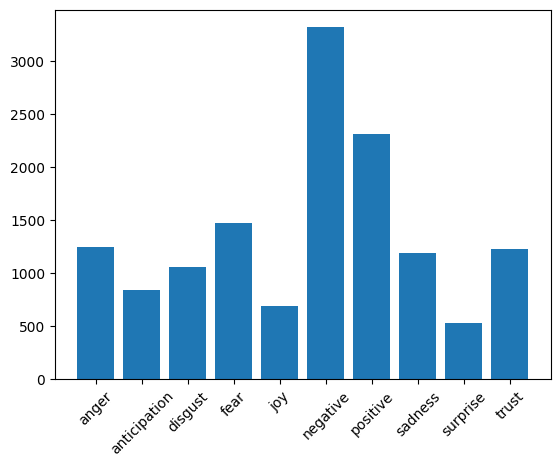

In [50]:
import matplotlib.pyplot as plt

label_counts = df[emotion_cols].sum(axis=0)

plt.figure()
plt.bar(emotion_cols, label_counts)
plt.xticks(rotation=45)
plt.show()

## Ejercicio 2: Tomando como entrada el dataset que acabas de construir en el apartado anterior:

### Selecciona y entrena al menos 2 algoritmos de aprendizaje automático no basados en redes neuronales para clasificar emociones. Explica por qué has decidido seleccionar esos modelos.

En el anterior ejercicio construimos un dataset sintético de frases cortas utilizando diferentes palabras del Word-Emotion Association Lexicon del National Research Council, etiquetadas con diversas emociones y su polaridad. Un mismo término puede tener asociadas más de una emoción, por lo que nos encontramos ante un problema de clasificación multietiqueta (sobre textos cortos).

Uno de los algoritmos que vamos a probar es la Regresión Logística, porque hace una buena combinación con TF-IDF (Term Frequency - Inverse Document Frequency, lo discutiremos en más profundidad más adelante en este ejercicio) y los n-gramas de palabra o de caracteres.

El otro que hemos seleccionado es el SGDClassifier, porque nuestro dataset, al contar con casi 6500 patrones, es considerablemente grande. Utilizaremos la función de pérdida _hinge_ para que se comporte como una SVM lineal, porque tenemos un espacio altamente dimensional.

Antes de entrenar el modelo, necesitamos definir algunos criterios más, planteados por otros apartados de esta pregunta, por lo que vamos a responderlos a todos antes de dedicarnos a entrenar.

### Señala cuál ha sido tu política para la construcción de conjuntos de entrenamiento, validación y test.

Se ha dividido el dataset de la siguiente manera: 70% se destinará al entrenamiento de los modelos, 15% para validarlos y el 15% para su test. La división se hará de manera aleatoria e intentando mantener la distribución de etiquetas en los distintos subconjuntos.

### Identifica al menos 2 modelos de vectorización del texto diferentes con los que entrenar cada algoritmo elegido. Pueden ser vectores dispersos o densos. Justifica por qué has elegido esos modelos y no otros.

Hemos elegido comparar Bag of Words, que representa vectoriza los documentos basándose en la frecuencia de vocablos; con TF-IDF, que lo hace evaluando la importancia de las diversas palabras del documento. Se configurarán con tanto unigramas como bigramas para capturar no sólo la presencia individual de palabras, sino también pequeñas estructuras contextuales de las mismas, como puede ser la negación ("not good") de éstas.

### Usa las métricas más adecuadas que te permitan analizar la eficacia de los modelos. Contrasta los valores obtenidos.

Como nuestro problema es multietiqueta, no deberíamos utilizar _Accuracy_, que es una métrica bastante clásica. _Precision_ (Proporción de predicciones correctas sobre todas las predicciones de una misma clase) y _Recall_ (Proporción de ejemplos de una misma clase que han sido clasificados correctamente) son métricas más robustas.

$$
\text{Precision} = \frac{\text{True Positive}}{\text{False Positive}+\text{True Positive}}
$$

$$
\text{Recall} = \frac{\text{True Positive}}{\text{False Negative}+\text{True Positive}}
$$

Sin embargo, al estar ser un problema de clasificación multietiqueta, utilizaremos el _F1-Score_, que combina a las dos anteriores mediante la media armónica, para penalizar grandes diferencias entre ambas y así luchar contra el desbalanceo del dataset.

$$
F_1 = 2 \cdot \frac{\text{Precision}\cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

También utilizaremos la _Hamming Loss_, que es la fracción de etiquetas que han sido predichas de manera incorrecta.

-------

Ahora podemos proceder a resolver el ejercicio. Empezamos por la división del dataset en conjuntos de _train_, _validation_ y _test_.

In [51]:
import pandas as pd
from skmultilearn.model_selection import iterative_train_test_split

df = pd.read_csv("data.tsv", sep="\t")

emotion_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "negative", "positive", "sadness", "surprise",
    "trust"
]

X = df["phrase"].to_numpy().reshape(-1, 1)
y = df[emotion_cols].to_numpy()

X_train, y_train, X_temp, y_temp = iterative_train_test_split(
    X, y, test_size=0.3
)

X_val, y_val, X_test, y_test = iterative_train_test_split(
    X_temp, y_temp, test_size=0.5
)

X_train = X_train.ravel()
X_val = X_val.ravel()
X_test = X_test.ravel()

A continuación, realizamos las distintas vectorizaciones sobre los datos de entrenamiento:

In [52]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow = CountVectorizer(ngram_range=(1,2))
tfidf = TfidfVectorizer(ngram_range=(1,2))

X_train_bow = bow.fit_transform(X_train)
X_val_bow = bow.transform(X_val)
X_test_bow = bow.transform(X_test)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

Ahora vamos a realizar un estudio de los hiperparámetros para cada combinación de modelo clasificador y modelo de vectorización.

In [53]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from tqdm import tqdm

#### Regresión Logística

In [54]:
best_score_reglog_bow = 0
best_model_reglog_bow = None
best_C_reglog_bow = None

for C in tqdm([0.01, 0.1, 1, 10]):
    model = OneVsRestClassifier(LogisticRegression(C=C, class_weight="balanced"))
    model.fit(X_train_bow, y_train)

    score = f1_score(y_val, model.predict(X_val_bow), average="micro")

    if score > best_score_reglog_bow:
        best_score_reglog_bow = score
        best_model_reglog_bow = model
        best_C_reglog_bow = C

print(f"Best C: {best_C_reglog_bow} - Val. Score: {best_score_reglog_bow}")

100%|██████████| 4/4 [00:02<00:00,  1.42it/s]

Best C: 0.01 - Val. Score: 0.3949526813880126


In [55]:
best_score_reglog_tfidf = 0
best_model_reglog_tfidf = None
best_C_reglog_tfidf = None

for C in tqdm([0.01, 0.1, 1, 10]):
    model = OneVsRestClassifier(LogisticRegression(C=C, class_weight="balanced"))
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_val_tfidf)

    score = f1_score(y_val, preds, average="micro")

    if score > best_score_reglog_tfidf:
        best_score_reglog_tfidf = score
        best_model_reglog_tfidf = model
        best_C_reglog_tfidf = C

print(f"Best C: {best_C_reglog_tfidf} - Val. Score: {best_score_reglog_tfidf}")

100%|██████████| 4/4 [00:01<00:00,  3.38it/s]

Best C: 0.1 - Val. Score: 0.4092920353982301


#### SGD

In [56]:
best_score_sgd_bow = 0
best_model_sgd_bow = None
best_alpha_sgd_bow = None

for alpha in tqdm([0.01, 0.1, 1, 10]):
    model = OneVsRestClassifier(SGDClassifier(loss="hinge", alpha=alpha, class_weight="balanced"))
    model.fit(X_train_bow, y_train)
    preds = model.predict(X_val_bow)

    score = f1_score(y_val, preds, average="micro")

    if score > best_score_sgd_bow:
        best_score_sgd_bow = score
        best_model_sgd_bow = model
        best_alpha_sgd_bow = alpha

print(f"Best alpha: {best_alpha_sgd_bow} - Val. Score: {best_score_sgd_bow}")

100%|██████████| 4/4 [00:00<00:00, 10.09it/s]

Best alpha: 0.01 - Val. Score: 0.40888107276324465


In [57]:
best_score_sgd_tfidf = 0
best_model_sgd_tfidf = None
best_alpha_sgd_tfidf = None

for alpha in tqdm([0.0001, 0.001, 0.01]):
    model = OneVsRestClassifier(SGDClassifier(loss="hinge", alpha=alpha, class_weight="balanced"))
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_val_tfidf)

    score = f1_score(y_val, preds, average="micro")

    if score > best_score_sgd_tfidf:
        best_score_sgd_tfidf = score
        best_model_sgd_tfidf = model
        best_alpha_sgd_tfidf = alpha

print(f"Best alpha: {best_alpha_sgd_tfidf} - Val. Score: {best_score_sgd_tfidf}")

100%|██████████| 3/3 [00:00<00:00, 12.35it/s]

Best alpha: 0.001 - Val. Score: 0.41165681679233745


Ahora ya tenemos los mejores modelos de cada tipo, procedemos a compararlos sobre los datos de test:

In [58]:
from sklearn.metrics import hamming_loss

In [59]:
models_bow = {
    "RegLog - BoW": best_model_reglog_bow,    
    "SGD - BoW": best_model_sgd_bow
}

models_tfidf = {
    "RegLog - TFIDF": best_model_reglog_tfidf,    
    "SGD - TFIDF": best_model_sgd_tfidf,    
}

models_metrics = {}

def calculate_metrics(y_test, preds):
    f1_micro = f1_score(y_test, preds, average="micro")
    f1_macro = f1_score(y_test, preds, average="macro")
    hamming = hamming_loss(y_test, preds)

    return f1_micro, f1_macro, hamming

for model_name, model in models_bow.items():
    preds = model.predict(X_test_bow)
    models_metrics[model_name] = (calculate_metrics(y_test, preds))

for model_name, model in models_tfidf.items():
    preds = model.predict(X_test_tfidf)
    models_metrics[model_name] = (calculate_metrics(y_test, preds))

models_metrics

{'RegLog - BoW': (0.3937732953299715, 0.33195780096049127, 0.2960385438972163),
 'SGD - BoW': (0.42317266349852906, 0.3458459029266415, 0.2729122055674518),
 'RegLog - TFIDF': (0.40157116451016633,
  0.3276457812833634,
  0.2773019271948608),
 'SGD - TFIDF': (0.4073363190445724, 0.3434410270226558, 0.29753747323340474)}

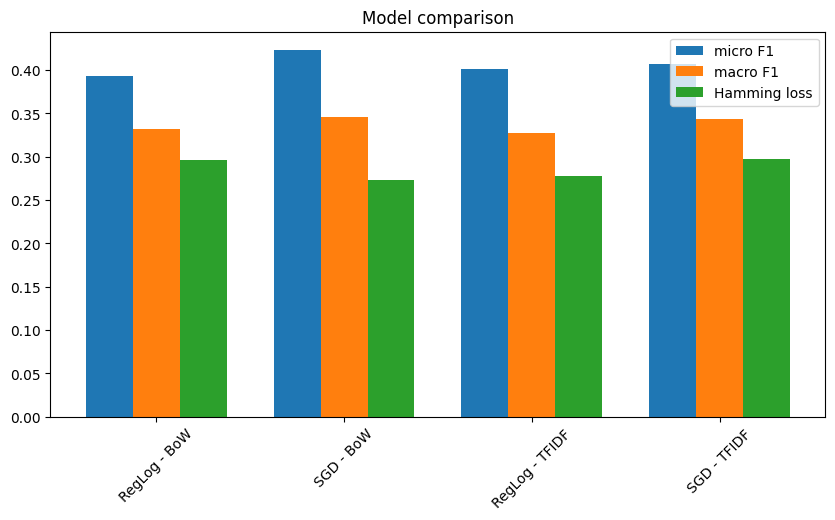

Best micro F1 : 0.4232 -> SGD - BoW
Best macro F1: 0.3458 -> SGD - BoW
Best Hamming loss: 0.2729 -> SGD - BoW


In [60]:
import numpy as np
import matplotlib.pyplot as plt

labels = list(models_metrics.keys())
values = np.array(list(models_metrics.values()))

f1_micro = values[:, 0]
f1_macro = values[:, 1]
hamming = values[:, 2]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - width, f1_micro, width, label="micro F1")
plt.bar(x, f1_macro, width, label="macro F1")
plt.bar(x + width, hamming, width, label="Hamming loss")

plt.xticks(x, labels, rotation=45)
plt.title("Model comparison")
plt.legend()
plt.show()

best_micro_idx = np.argmax(f1_micro)
best_macro_idx = np.argmax(f1_macro)
best_hamming_idx = np.argmin(hamming)

print(f"Best micro F1 : {f1_micro[best_micro_idx]:.4f} -> {labels[best_micro_idx]}")
print(f"Best macro F1: {f1_macro[best_macro_idx]:.4f} -> {labels[best_macro_idx]}")
print(f"Best Hamming loss: {hamming[best_hamming_idx]:.4f} -> {labels[best_hamming_idx]}")

A la luz de los resultados, observamos que los modelos presentan un rendimiento muy similar en todas las métricas. En general, la mejor configuración ha sido utilizar SGD y BoW, tanto desde el punto del rendimiento global (micro F1) como de cara al equilibrio entre etiquetas (macro F1). 

Todos los modelos obtienen valores bastante similares de Hamming Loss, lo que parece indicar un comportamiento homogéneo en cuanto al nivel de error por etiqueta el cual, a pesar de haber corregido el desbalance de clases mediante el parámetro "class_weight" durante el entrenamiento, sigue siendo considerablemente alto lo cual, en conjunción con la similitud de resultados entre modelos, parece indicar que no se trata de un problema de elección de clasificadores o vectorizadores; sino que la dificultad proviene de la naturaleza sintética del dataset y la propia complejidad de la clasificación multietiqueta de las emociones.

### Una vez entrenados, validados y evaluados los modelos, implementa la funcionalidad para guardarlos de forma local y poder recuperarlos más tarde.

In [63]:
import joblib

path = "./models/"

joblib.dump(best_model_reglog_bow, path+"model_reglog_bow.pkl")
joblib.dump(best_model_sgd_bow, path+"model_sgd_bow.pkl")
joblib.dump(best_model_reglog_tfidf, path+"model_reglog_tfidf.pkl")
joblib.dump(best_model_sgd_tfidf, path+"model_sgd_tfidf.pkl")
joblib.dump(bow, path+"vectorizer_bow.pkl")
joblib.dump(tfidf, path+"vectorizer_tfidf.pkl")

['./models/vectorizer_tfidf.pkl']

## Ejercicio 3: Implementa una función que permita analizar texto y proporcionar emociones vinculadasa él. Esta función debe:

- Recibir el texto a analizar, y uno de los algoritmos que has entrenado en apartados anteriores.

- Devolver, un diccionario donde las claves sean emociones del NRC y vinculadas con cada clave, el nivel de emoción que ha identificado. ¿Qué estrategia has empleado para decidir el nivel de cada emoción en el texto completo?

In [71]:
from typing import Literal

def analyze_emotions(text: str, model_path: str, model: Literal["sgd", "reglog"], vectorizer: Literal["bow", "tfidf"]):
    model_obj = joblib.load(f"{model_path}/model_{model}_{vectorizer}.pkl")
    vectorizer_obj = joblib.load(f"{model_path}/vectorizer_{vectorizer}.pkl")

    emotion_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "negative", "positive", "sadness", "surprise",
    "trust"
    ]

    X = vectorizer_obj.transform([text])
    probs = model_obj.decision_function(X)

    emotions = {}
    for i, emotion in enumerate(emotion_cols):
        emotions[emotion] = float(probs[0][i])

    return emotions

Se ha implementado una función que, dado un texto y unas configuraciones (clasificador-vectorizador), carga la opción elegida de modelo de entre los entrenados en el ejercicio anterior y analiza la intensidad de cada emoción.

Hemos abordado el problema desde una perspectiva probabilística, utilizando las probabilidades generadas por los clasificadores, que muestran el grado de confianza del modelo respecto a cada clase dentro del esquema One-vs-Rest; puesto que el léxico utilizado, EmoLex, simplemente utiliza una codificación binaria de las 8 emociones básicas de Plutchik para cada uno de los vocablos que contempla.

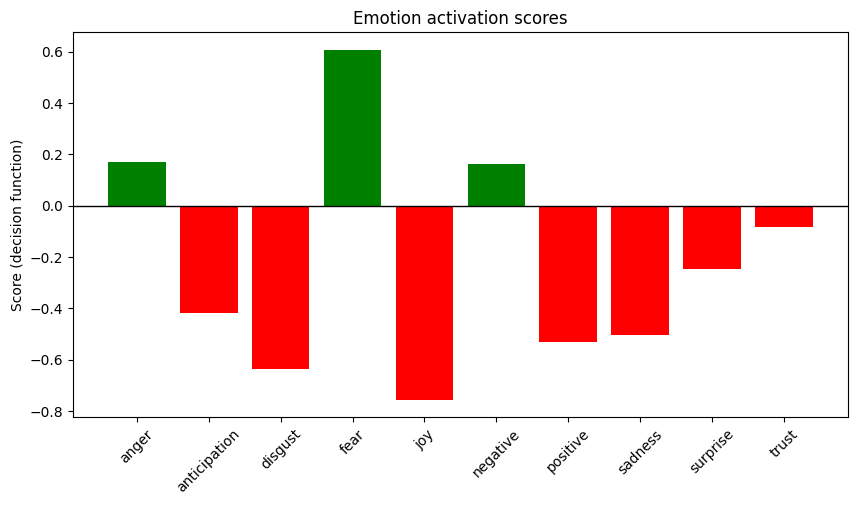

The quick brown fox jumps over the lazy dog.
{'anger': 0.168776387541548, 'anticipation': -0.4176927040030889, 'disgust': -0.635999211926348, 'fear': 0.6079257238951533, 'joy': -0.7564189883446802, 'negative': 0.16104520978700776, 'positive': -0.531287583521154, 'sadness': -0.5057087101433458, 'surprise': -0.2470966547918989, 'trust': -0.08282187331781846}


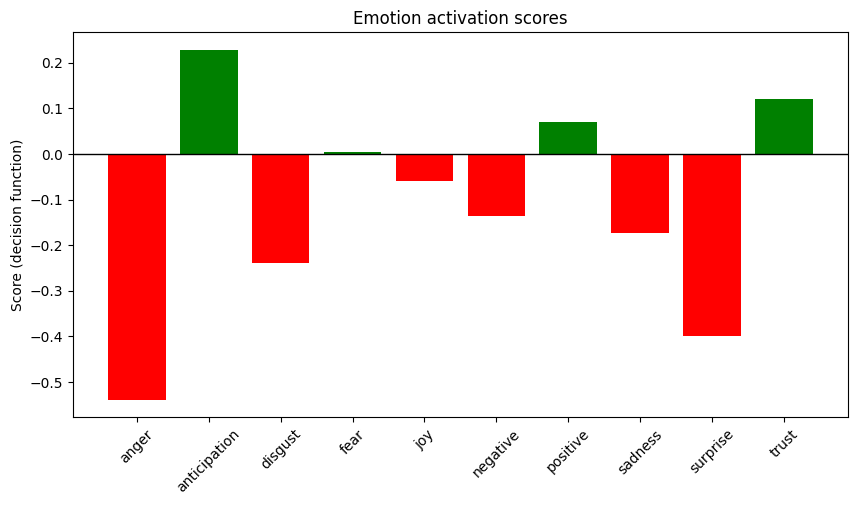

Today's weather is very sunny.
{'anger': -0.5387425046542025, 'anticipation': 0.2285636823712668, 'disgust': -0.23815349259549598, 'fear': 0.0030625862481784005, 'joy': -0.05907720594609807, 'negative': -0.1369342175762778, 'positive': 0.06886187077144999, 'sadness': -0.17246574597566428, 'surprise': -0.3997059419870994, 'trust': 0.11980287738501506}


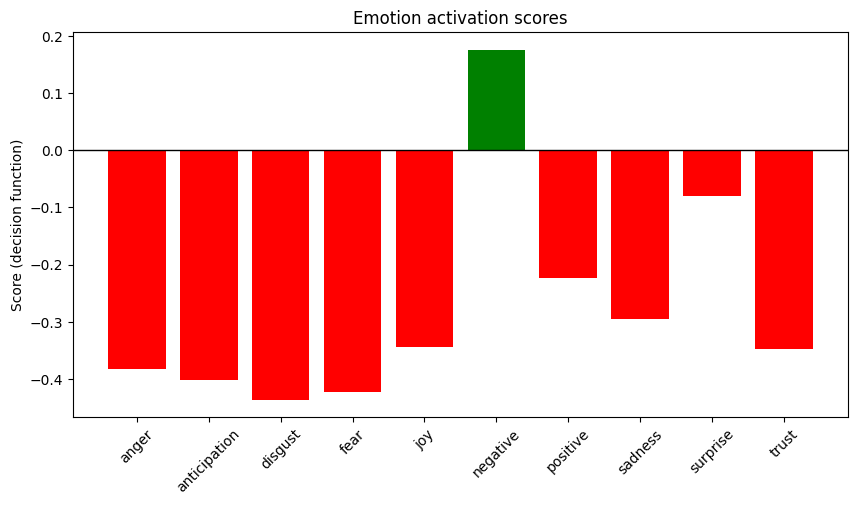

Yesterday was a rainy day and the children couldn't play outside.
{'anger': -0.3830769693791795, 'anticipation': -0.4016254948170883, 'disgust': -0.43589638237572204, 'fear': -0.4224136050426082, 'joy': -0.34431091507520173, 'negative': 0.17592139573841814, 'positive': -0.22250477037445018, 'sadness': -0.29489489566595317, 'surprise': -0.07958340636960515, 'trust': -0.3473553631265317}


In [91]:
texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Today's weather is very sunny.",
    "Yesterday was a rainy day and the children couldn't play outside."
]

for text in texts:

    result = analyze_emotions(text, "./models", "sgd", "bow")

    plt.figure(figsize=(10,5))

    colors = ["green" if v >= 0 else "red" for v in result.values()]

    plt.bar(result.keys(), result.values(), color=colors)

    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(rotation=45)
    plt.title("Emotion activation scores")
    plt.ylabel("Score (decision function)")
    plt.show()

    print(text)
    print(result)

Hemos probado la función con tres frases distintas. En la primera de ellas, el modelo ve fuerte presencia de las emociones negativas, de ira y de miedo; y duda mucho de otras emociones como puede ser la alegría.

En la segunda oración, se encuentra bastante neutral con la posible presencia de miedo; y, por ejemplo, ve una fuerte presencia de anticipación a la vez que una fuerte ausencia de ira.

En la última, sin embargo, percibe una ausencia fuerte para la mayoría de las emociones, aunque para algunas está más indeciso y para la polaridad negativa, ve una presencia fuerte.

Sin embargo, no deberíamos interpretar estos resultados como una detección literal de emociones, sino como la activación del modelo ante patrones lingüísticos similares a los que fueron observados durante su entrenamiento; sobretodo teniendo en cuenta las limitaciones previamente descritas con el proceso de análisis de intensidad y en el ejercicio anterior con el entrenamiento de los modelos.

